In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import geopandas as gpd
import matplotlib.patheffects as pe
import utils

In [31]:
df = pd.read_csv('../data/Raw/Louisville_Metro_KY_-_Library_Collection_Inventory_.csv')

In [32]:
df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,Main,25.95,2022/07/01 04:00:00+00,1
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,2
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,3
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,4
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,5


## Cleaning the Data  
The dataset contained several issues that must be addressed before analysis:  
- The 'BibNum', 'Author', 'ISBN', 'PublicationDate', and 'ReportDate' (if it is one date throughout the column) columns needed to be dropped as they were not necessary to answer questions I have about the data.
- Renamed leftover columns to match syntax used in other notebooks and sqlite.

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657555 entries, 0 to 1657554
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   BibNum           1657555 non-null  int64  
 1   Title            1657554 non-null  object 
 2   Author           1461831 non-null  object 
 3   ISBN             1422972 non-null  float64
 4   PublicationYear  1657555 non-null  int64  
 5   ItemType         1657555 non-null  object 
 6   ItemCollection   1657350 non-null  object 
 7   ItemLocation     1657555 non-null  object 
 8   ItemPrice        1657555 non-null  float64
 9   ReportDate       1657555 non-null  object 
 10  ObjectId         1657555 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 139.1+ MB


In [34]:
df['ReportDate'].unique()

array(['2022/07/01 04:00:00+00'], dtype=object)

In [35]:
df.drop(['ReportDate'], axis=1, inplace=True)

In [36]:
df.drop(['BibNum','Author', 'ISBN', 'PublicationYear'], axis=1, inplace=True)

In [37]:
df = df.rename(columns={'ObjectId': 'item_id', 'Title':'title', 'ItemType':'item_type', 'ItemCollection': 'item_collection', 'ItemLocation':'item_location', 'ItemPrice':'item_price'})

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657555 entries, 0 to 1657554
Data columns (total 6 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   title            1657554 non-null  object 
 1   item_type        1657555 non-null  object 
 2   item_collection  1657350 non-null  object 
 3   item_location    1657555 non-null  object 
 4   item_price       1657555 non-null  float64
 5   item_id          1657555 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 75.9+ MB


## EDA
Missing data was handled as shown below:
- The row with 'Title' == NaN was dropped as it contains very little data.
- Due to a very low percentage of 'ItemCollection' == NaN and the wide variety of options regarding 'ItemCollection', it was left as is.
- For instances where 'ItemPrice' is equal to 0, it was left as is since there is no way to verify from the data if the data is missing or is equal to 0 as not all items in the library collection have an item price (donations).

Any visualizations using columns with missing data will be noted in the visualization markdown.

Regarding duplicated rows, rows cannot be validated as duplicated data or as simply duplicate items in the library inventory.

In [39]:
df.isna()

df.isna().sum()

title                1
item_type            0
item_collection    205
item_location        0
item_price           0
item_id              0
dtype: int64

In [40]:
df.loc[df['title'].isna()]

,title,item_type,item_collection,item_location,item_price,item_id
243965,NaN,Book,NaN,Crescent Hill,0.0,243966


In [41]:
df = df.drop(243965)

In [42]:
df.isna().sum()

title                0
item_type            0
item_collection    204
item_location        0
item_price           0
item_id              0
dtype: int64

In [43]:
df.loc[df['item_collection'].isna()]

,title,item_type,item_collection,item_location,item_price,item_id
8026,LANKIE MANTITA,Book,NaN,Shively,0.0,8027
8587,My First Pet,Book,NaN,Newburg,0.0,8588
10501,Act of War,Book,NaN,Bon Air,0.0,10502
16848,FOUR,Book,NaN,Crescent Hill,0.0,16849
22165,designing your work life,Book,NaN,St Matthews,0.0,22166
...,...,...,...,...,...,...
1656927,The Khipu and the Final Key,Book,NaN,Northeast,0.0,1656928
1656933,MOMMY'S DISEASE,Book,NaN,Southwest,0.0,1656934
1657038,use,Book,NaN,Northeast,0.0,1657039
1657505,the girl in the road,Book,NaN,Main,0.0,1657506


In [44]:
df.item_collection.unique()

array(['Adult Non-Fiction', 'ELL Collection', 'Adult Fiction', 'Mystery',
       'Adult Audiobook', 'Adult DVD', 'Electronic', 'Music',
       "Children's Picture Book", 'Science Fiction',
       'Book Discussion Kit', 'Older Teen Fiction',
       'Younger Teen  Fiction', 'Adult Paperback', "Children's Fiction",
       'Western', "Children's Picture Paperback", "Children's Paperback",
       'International Collection', 'Teen Non-Fiction',
       "Children's Non-Fiction", 'Kentucky History', 'Natural Resources',
       'Oversize', 'Holiday', 'Urban Fiction', 'Bestsellers',
       "Children's Board Book", 'Storytime Collection',
       'Preschool  Picture Book', "Children's Easy Reader", 'Readalongs',
       "Children's DVD", "Children's Reference", 'Adult Reference',
       'Interlibrary Loan', "Children's Music", nan,
       'Adult Paperbacks Tall', "Children's Easy Reader Paperback",
       'Large Print', 'Caldecott/Newbery', "Children's Audiobook",
       'OlderTeen Audiobook', 'Youn

In [45]:
item_collection_na = df.item_collection.isna().sum()
total_rows = df.shape[0]
per_item_collection_na = (item_collection_na / total_rows) * 100
per_item_collection_na

np.float64(0.01230729134616429)

In [46]:
zero_item_price = df[df['item_price'] == 0]
zero_item_price

,title,item_type,item_collection,item_location,item_price,item_id
99,The Cornwalls Vanish,Ebook,Electronic,Main,0.0,100
350,The Best Cook in the World,Ebook,Electronic,Main,0.0,351
351,The Art of Tapestry Weaving,Ebook,Electronic,Main,0.0,352
352,Cornwall's Wonderland,Ebook,Electronic,Main,0.0,353
353,Target: Alex Cross,Ebook,Electronic,Main,0.0,354
...,...,...,...,...,...,...
1657502,A Duke for Diana,Ebook,Electronic,Main,0.0,1657503
1657503,Secret City,Eaudiobook,Electronic,Main,0.0,1657504
1657504,Secret City,Eaudiobook,Electronic,Main,0.0,1657505
1657505,the girl in the road,Book,NaN,Main,0.0,1657506


In [47]:
df['item_price'] = df['item_price'].apply(lambda x: f'${x:,.2f}')

In [48]:
df[df['item_price'] == 0.0]

,title,item_type,item_collection,item_location,item_price,item_id


In [49]:
duplicated_mask = df.duplicated(keep=False)
duplicated_rows = df[duplicated_mask]
duplicated_rows

,title,item_type,item_collection,item_location,item_price,item_id


## SQL Queries and Visualizations

In [105]:
connection = sqlite3.connect("../database/lfpl_oss_household_demographics.db")
cursor = connection.cursor()

In [106]:
#Percentage of Zipcodes with a Library
query1 = pd.read_sql('''
SELECT COUNT(DISTINCT l.zipcode) AS zipcodes_with_library,
    COUNT(DISTINCT lz.zipcode) AS total_louisville_zipcodes,
    COUNT(DISTINCT l.zipcode) * 100 / COUNT(DISTINCT lz.zipcode) AS library_zipcodes_pct
FROM libraries l
RIGHT JOIN louisville_zipcodes lz ON l.zipcode = lz.zipcode;
''', connection)
query1

,zipcodes_with_library,total_louisville_zipcodes,library_zipcodes_pct
0,17,41,41


In [107]:
#Percentage of OSS Zipcodes with a Library
query2 = pd.read_sql('''
SELECT COUNT(DISTINCT l.zipcode) AS zipcodes_with_library,
    COUNT(DISTINCT o.zipcode) AS oss_household_zipcodes,
    COUNT(DISTINCT l.zipcode) * 100 / COUNT(DISTINCT o.zipcode) AS library_oss_zipcode_pct
FROM oss_households o
LEFT JOIN libraries l ON o.zipcode = l.zipcode;
''', connection)
query2

,zipcodes_with_library,oss_household_zipcodes,library_oss_zipcode_pct
0,17,38,44


In [108]:
lfpl_loc = gpd.read_file("../data/Raw/Louisville_KY_Free_Public_Libraries/Louisville_KY_Free_Public_Libraries.shp")
zipcodes = gpd.read_file("../data/Raw/Jefferson_County_KY_ZIP_Codes/Jefferson_County_KY_ZIP_Codes.shp")

In [109]:
query3 = pd.read_sql('''
SELECT zipcode, COUNT(*) AS oss_households
FROM oss_households
GROUP BY zipcode;
''', connection)
query3

,zipcode,oss_households
0,40023,14
1,40041,3
2,40047,14
3,40059,62
4,40109,4
5,40118,531
6,40177,14
7,40202,809
8,40203,3579
9,40204,589


In [110]:
oss_households_map = zipcodes.merge(query3, left_on='ZIPCODE', right_on='zipcode', how='left')

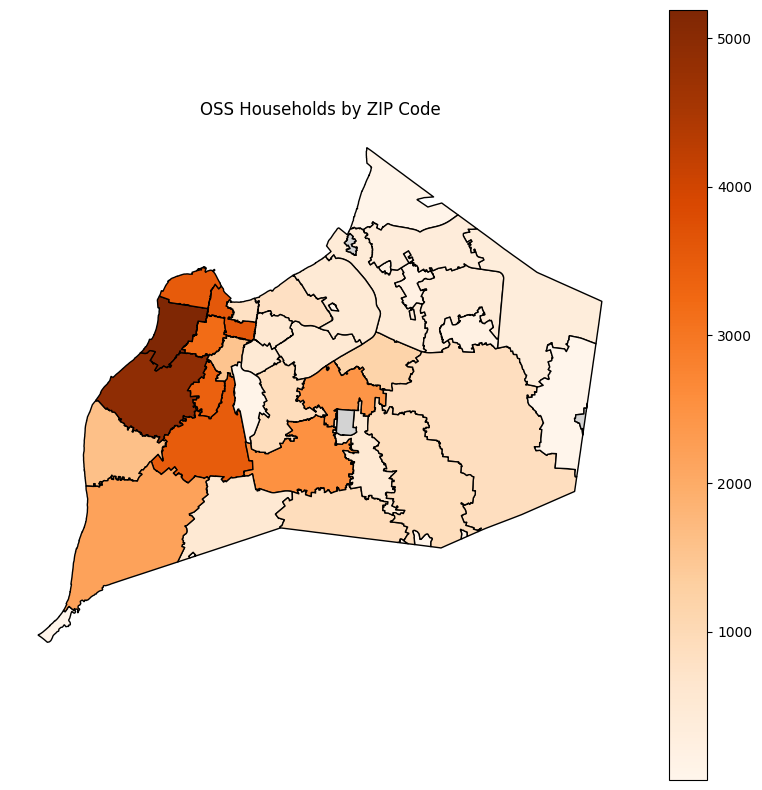

In [111]:
ax = oss_households_map.plot(
    column='oss_households',
    cmap='Oranges',
    figsize=(10, 10),
    edgecolor='black',
    legend=True,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title('OSS Households by ZIP Code', fontsize=12)
ax.axis('off')

plt.savefig('../plots/OSSHouseholdsMap.png')
plt.show()

In [112]:
#OSS Household Count per Library Branch
query4 = pd.read_sql('''
SELECT 
    o.zipcode,
    l.library_name,
    COUNT(o.household_id) AS household_count
FROM libraries l
JOIN oss_households o 
    ON l.zipcode = o.zipcode
GROUP BY o.zipcode, l.library_name
ORDER BY household_count DESC;
''', connection)
query4

,zipcode,library_name,household_count
0,40211,PARKLAND,5189
1,40211,SHAWNEE,5189
2,40216,SHIVELY,4919
3,40203,MAIN,3579
4,40203,WESTERN,3579
5,40212,PORTLAND,3521
6,40215,IROQUOIS,3405
7,40219,SOUTH CENTRAL REGIONAL,2518
8,40218,NEWBURG,2441
9,40272,SOUTHWEST REGIONAL,2174


In [113]:
utils.name_fix(query4, 'library_name', lfpl_loc, 'LFPL_NAME')

In [114]:
households_map = lfpl_loc.merge(query4, left_on='LFPL_NAME', right_on='library_name', how='left')

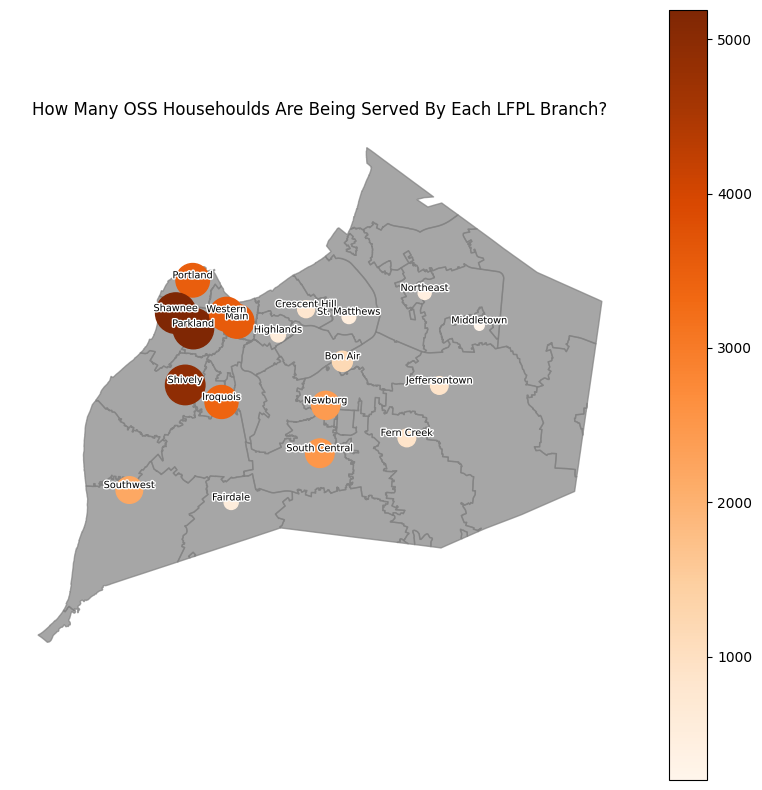

In [115]:
utils.lfpl_map(zipcodes, households_map, 'household_count', 'How Many OSS Househoulds Are Being Served By Each LFPL Branch?', pe, plt, '../plots/OSSHouseholdsPerBranchMap.png')


In [116]:
#Average Annual Income of OSS Households per Library Branch
query5 = pd.read_sql('''
SELECT l.library_name, ROUND(AVG(o.annual_income), 2) as avg_oss_household_annual_income
FROM oss_households o
JOIN libraries l ON o.zipcode = l.zipcode
GROUP BY l.library_name
ORDER BY avg_oss_household_annual_income;
''', connection)
query5

,library_name,avg_oss_household_annual_income
0,MAIN,10167.11
1,WESTERN,10167.11
2,PARKLAND,10912.68
3,SHAWNEE,10912.68
4,PORTLAND,11268.57
5,IROQUOIS,11645.28
6,NEWBURG,12237.14
7,SHIVELY,12408.62
8,CRESCENT HILL,12569.77
9,HIGHLANDS-SHELBY PARK,12857.28


In [117]:
utils.name_fix(query5, 'library_name', lfpl_loc, 'LFPL_NAME')

In [118]:
query5['avg_oss_household_annual_income'] = query5['avg_oss_household_annual_income'].astype('int64')

In [119]:
annual_income_map = lfpl_loc.merge(query5, left_on='LFPL_NAME', right_on='library_name', how='left')

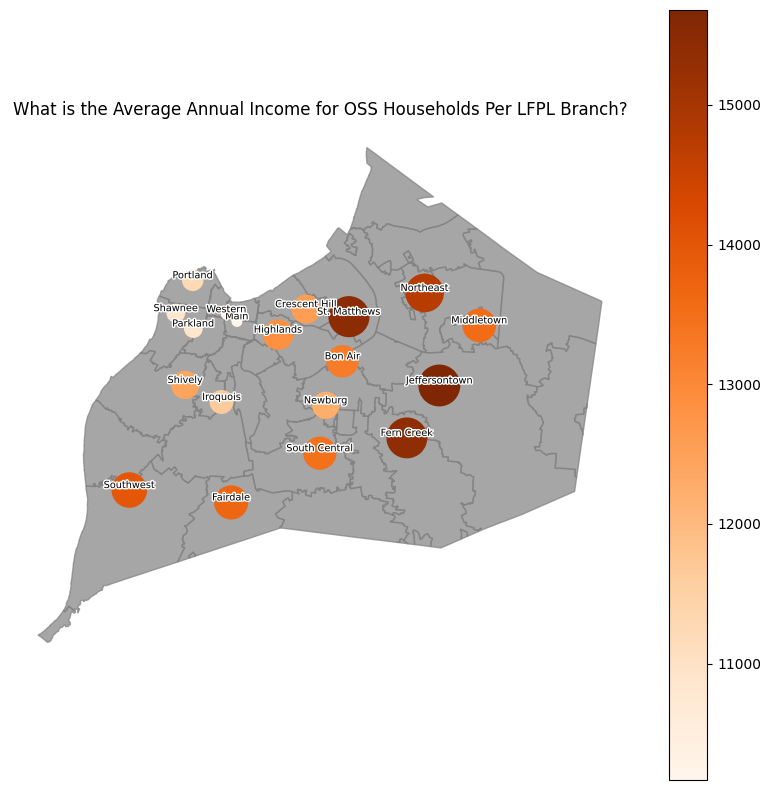

In [120]:
utils.lfpl_map(zipcodes, annual_income_map, 'avg_oss_household_annual_income', 'What is the Average Annual Income for OSS Households Per LFPL Branch?', pe, plt, '../plots/OSSAnnualIncomePerBranchMap.png')


## EDA Plots (Item Totals)
Total Items by Library Branch:
- Bar charts were used in this section to show the distribution of the library collection as a whole and the book collection across all the library branches. A simple blue color was chosen for the bar charts used for the visualization folder. The goal was to keep the charts readable and focused on their objective.
- Some 'ItemLocation' entries needed to be combined to get a total for the branch (i.e. 'Remote Shelving-Shawnee' to 'Shawnee').
- The 'ItemLocation' called 'Content Management' was replaced with the standard location, 'Main,' as it only applied to 3 items.
- A plot without the Main branch was included as it has a disproportionate amount of items compared to the other branches. I would like to see a clearer comparison of those branches.
- A scattered bar chart was not very helpful due to the large amount of item types, but it did help confirm that majority of the item types that are not books are located at the Main branch.   
- A bar chart showing only book items displayed an exact trend as seen in the bar chart of all item types in which the Main branch has the vast majority of items and the branches went in the same order with book count.

In [122]:
df['item_location'] = df['item_location'].replace('Remote Shelving - Shawnee', 'Shawnee')
df['item_location'] = df['item_location'].replace('Childrens Bookmobile', 'Bookmobile')
df['item_location'] = df['item_location'].replace('Adult Bookmobile', 'Bookmobile')
df['item_location'] = df['item_location'].replace(['Remote Shelving - Main', 'Childrens Main Library', 'Main Teen'], 'Main')

In [123]:
df[df['item_location'] == 'Content Management'].value_counts()

Series([], Name: count, dtype: int64)

In [124]:
df['item_location'] = df['item_location'].replace('Content Management', 'Main')

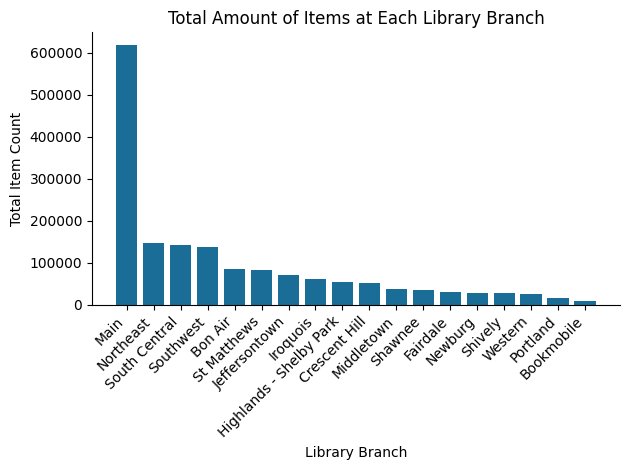

In [125]:
total_item_count = df['item_location'].value_counts()
total_item_count

plt.bar(total_item_count.index, total_item_count.values, color="#1A6D96")
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each Library Branch')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/TotalItemAtEachBranchBar.png')
plt.show()

In [126]:
items_per_branch = df.groupby('item_location')['item_type'].value_counts().reset_index().sort_values(by='count', ascending=True)
items_per_branch

,item_location,item_type,count
367,Western,Two Dimensional Nonprojected Graphic,1
185,Middletown,Manuscript Material,1
186,Middletown,Printed Cartographic Material,1
187,Middletown,Three Dimensional Object (Artifact),1
188,Middletown,Two Dimensional Nonprojected Graphic,1
...,...,...,...
282,South Central,Book,114719
303,Southwest,Book,118845
207,Northeast,Book,122316
135,Main,Ebook,151681


In [127]:
pivot_df = items_per_branch.pivot(
    index='item_location',
    columns='item_type',
    values='count'
).fillna(0)

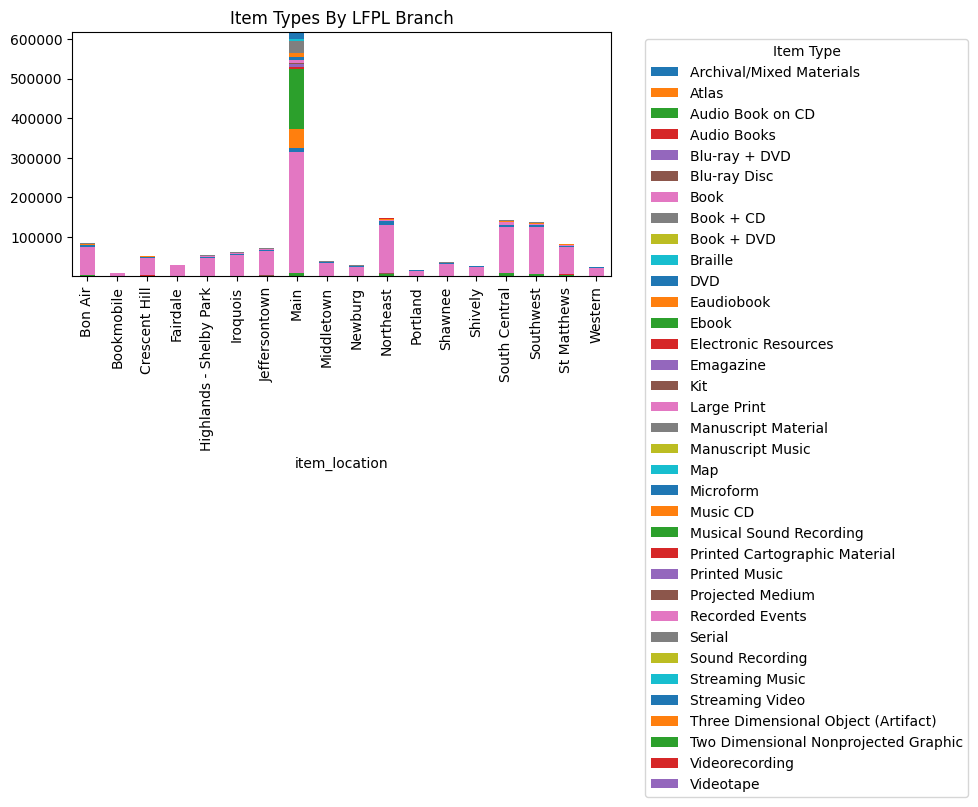

In [128]:
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(10,6))

ax.set_title('Item Types By LFPL Branch')

ax.legend(
    title='Item Type',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

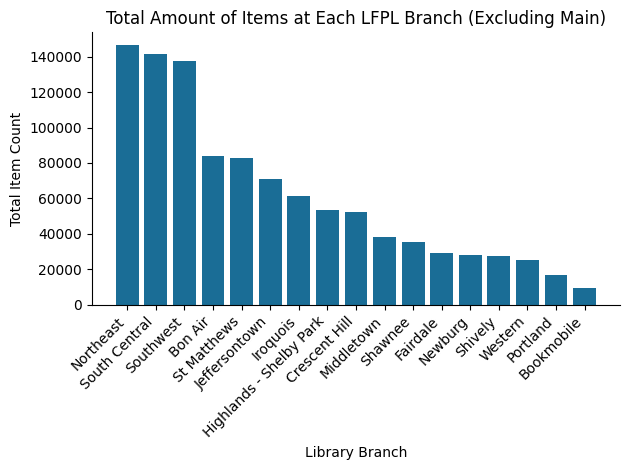

In [129]:
item_count_non_Main = (
    df[df['item_location'] != 'Main']['item_location']
    .value_counts())


plt.bar(item_count_non_Main.index, item_count_non_Main.values, color="#1A6D96")
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each LFPL Branch (Excluding Main)')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/TotalItemAtEachBranchExceptMainBar.png')
plt.show()

In [130]:
df.item_type.unique()

array(['Book', 'Audio Book on CD', 'DVD', 'Ebook', 'Music CD', 'Kit',
       'Eaudiobook', 'Atlas', 'Emagazine', 'Book + DVD', 'Videorecording',
       'Musical Sound Recording', 'Manuscript Material', 'Large Print',
       'Audio Books', 'Printed Music', 'Book + CD', 'Streaming Video',
       'Sound Recording', 'Braille', 'Serial',
       'Three Dimensional Object (Artifact)', 'Microform',
       'Electronic Resources', 'Blu-ray Disc', 'Recorded Events',
       'Streaming Music', 'Two Dimensional Nonprojected Graphic', 'Map',
       'Printed Cartographic Material', 'Videotape',
       'Archival/Mixed Materials', 'Projected Medium', 'Manuscript Music',
       'Blu-ray + DVD'], dtype=object)

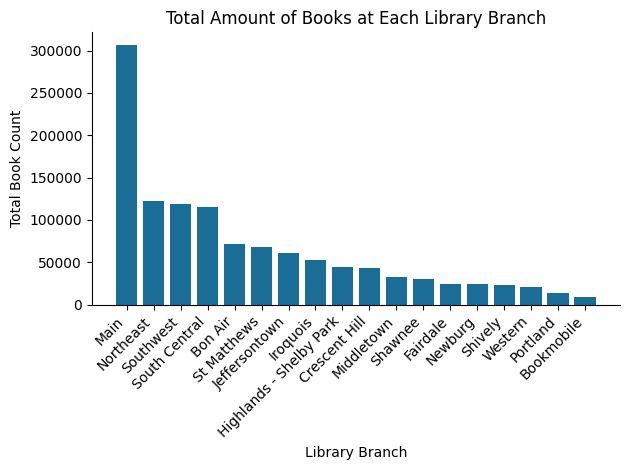

In [131]:
book_itemtype = df[df['item_type'] == 'Book']
book_count = book_itemtype.groupby('item_location')['item_type'].size().sort_values(ascending=False)
book_count

plt.bar(book_count.index, book_count.values, color="#1A6D96")
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Book Count')
plt.title('Total Amount of Books at Each Library Branch')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/TotalBooksAtEachBranchBar.png')
plt.show()

## EDA Plots (Geographic Coverage)
Are there areas in Louisville that are underserved in regard to the library?
- A Pin Map was a helpful visual when looking at how the library branches impact the geography of the Louisville area. A light grey background was chosen in order to highlight the smaller libraries with the lighter orange pins. The orange cmap selection allowed the pins to be more visible.
- The Main branch has the largest collection items, which makes sense as it is the oldest branch and also holds ownership over many of the electronic items.
- The Bookmobile location was not included as it does not have a set geographic location.

In [132]:
lfpl_loc = gpd.read_file("../data/Raw/Louisville_KY_Free_Public_Libraries/Louisville_KY_Free_Public_Libraries.shp")
inventory = pd.read_csv('../data/Clean/clean_lfpl_inventory.csv')
zipcodes = gpd.read_file("../data/Raw/Jefferson_County_KY_ZIP_Codes/Jefferson_County_KY_ZIP_Codes.shp")

In [133]:
book_itemtype = inventory[inventory['item_type'] == 'Book']
book_count = book_itemtype.groupby('item_location').size().reset_index(name='books')

In [134]:
book_count = book_count[book_count["item_location"] != "Bookmobile"]
book_count


,item_location,books
0,Bon Air,72029
2,Crescent Hill,43156
3,Fairdale,24385
4,Highlands - Shelby Park,44265
5,Iroquois,52738
6,Jeffersontown,61113
7,Main,306286
8,Middletown,32281
9,Newburg,23742
10,Northeast,122316


In [135]:
import utils

In [136]:
utils.name_fix(book_count, 'item_location', lfpl_loc, 'LFPL_NAME')

In [137]:
book_count_map = lfpl_loc.merge(book_count, left_on="LFPL_NAME", right_on="item_location")

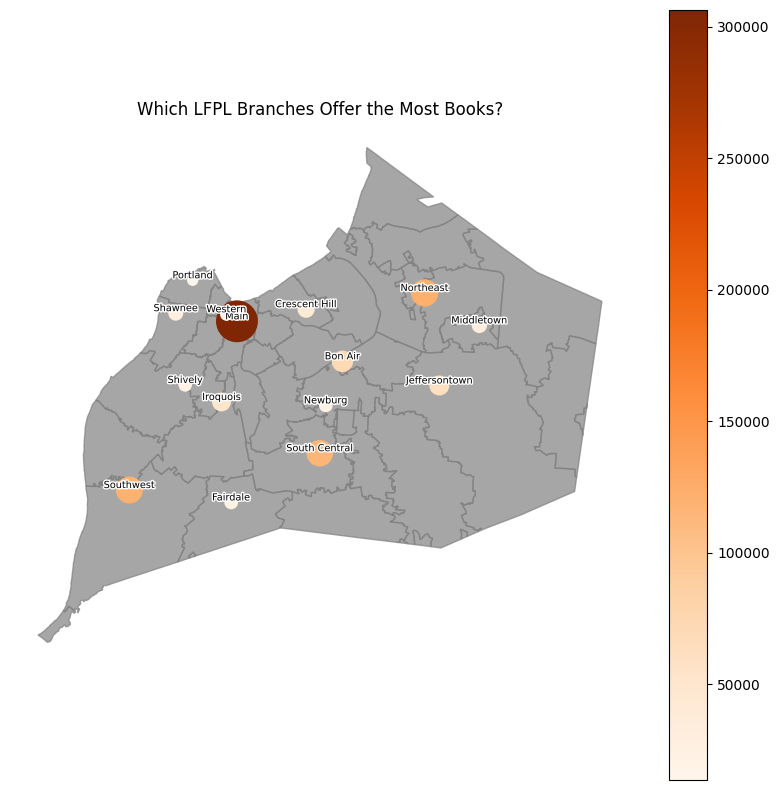

In [138]:
utils.lfpl_map(zipcodes, book_count_map, 'books', "Which LFPL Branches Offer the Most Books?", pe, plt, '../plots/TotalBooksPinMap.png')

## EDA (Comparisons within the Collection)
- A simple pie chart showed a comparison of LFPL Ebook versus Physical Book holdings.
- Heatmaps were used to show how the different item collections were disbursed across the different branches. They highlight some interesting aspects of certain branches such as the teens' collection is more spread out more among the branches than the children's collection and the items labeled as 'Kentucky History' are mostly housed at the Main branch, which highlights its use an archive.

In [139]:
df.item_type.unique()

array(['Book', 'Audio Book on CD', 'DVD', 'Ebook', 'Music CD', 'Kit',
       'Eaudiobook', 'Atlas', 'Emagazine', 'Book + DVD', 'Videorecording',
       'Musical Sound Recording', 'Manuscript Material', 'Large Print',
       'Audio Books', 'Printed Music', 'Book + CD', 'Streaming Video',
       'Sound Recording', 'Braille', 'Serial',
       'Three Dimensional Object (Artifact)', 'Microform',
       'Electronic Resources', 'Blu-ray Disc', 'Recorded Events',
       'Streaming Music', 'Two Dimensional Nonprojected Graphic', 'Map',
       'Printed Cartographic Material', 'Videotape',
       'Archival/Mixed Materials', 'Projected Medium', 'Manuscript Music',
       'Blu-ray + DVD'], dtype=object)

In [140]:
ebooks = df[df['item_type'].isin(['Ebook'])]

In [142]:
ebook_len = len(ebooks.value_counts())

In [143]:
book_len = len(df[df['item_type'] == 'Book'].value_counts())

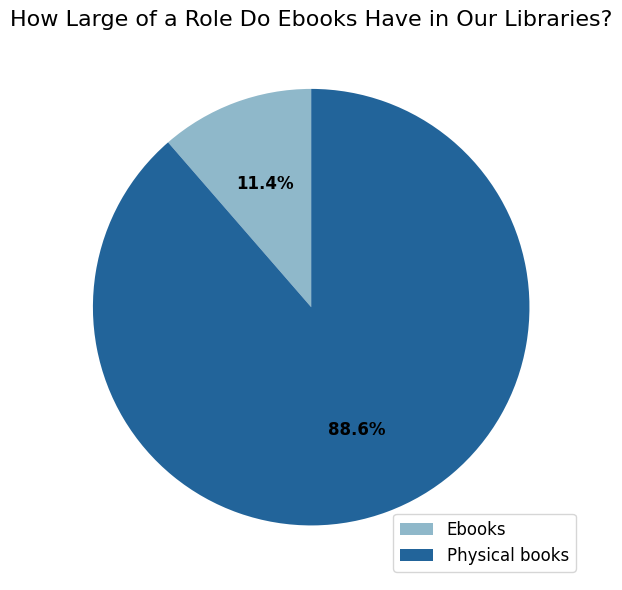

In [144]:
plt.figure(figsize=(6,6))
plt.pie(
    [ebook_len, book_len],
    labels=None,
    startangle=90,
    colors=["#8fb8caff", "#22649aff"],
    autopct='%1.1f%%',
    textprops={'fontsize' : 12, 'weight': 'bold'})

plt.title('How Large of a Role Do Ebooks Have in Our Libraries?', fontsize=16)
plt.legend(
    labels = ['Ebooks', 'Physical books'], fontsize=12,
    loc='lower right'
)


plt.tight_layout()
plt.savefig('../plots/BooksvsEbooksPieChart.png')
plt.show()


In [145]:
df['item_collection'].unique()

array(['Adult Non-Fiction', 'ELL Collection', 'Adult Fiction', 'Mystery',
       'Adult Audiobook', 'Adult DVD', 'Electronic', 'Music',
       "Children's Picture Book", 'Science Fiction',
       'Book Discussion Kit', 'Older Teen Fiction',
       'Younger Teen  Fiction', 'Adult Paperback', "Children's Fiction",
       'Western', "Children's Picture Paperback", "Children's Paperback",
       'International Collection', 'Teen Non-Fiction',
       "Children's Non-Fiction", 'Kentucky History', 'Natural Resources',
       'Oversize', 'Holiday', 'Urban Fiction', 'Bestsellers',
       "Children's Board Book", 'Storytime Collection',
       'Preschool  Picture Book', "Children's Easy Reader", 'Readalongs',
       "Children's DVD", "Children's Reference", 'Adult Reference',
       'Interlibrary Loan', "Children's Music", nan,
       'Adult Paperbacks Tall', "Children's Easy Reader Paperback",
       'Large Print', 'Caldecott/Newbery', "Children's Audiobook",
       'OlderTeen Audiobook', 'Youn

In [146]:
childrens_words = ['Children', 'Preschool', 'Storytime']
pattern = '|'.join(childrens_words)
childrens_df = df[
    df['item_collection'].str.contains(pattern, case=False, na=False)
]


In [147]:
childrens_df_byloc = childrens_df.groupby(['item_location', 'item_collection']).size().reset_index(name='count')
childrens_df_byloc


,item_location,item_collection,count
0,Bon Air,Children's Audiobook,283
1,Bon Air,Children's Blu-ray,63
2,Bon Air,Children's Board Book,950
3,Bon Air,Children's DVD,660
4,Bon Air,Children's Easy Reader,1194
...,...,...,...
297,Western,Children's Picture Book,1238
298,Western,Children's Picture Paperback,182
299,Western,Children's Reference,37
300,Western,Preschool Picture Book,1450


In [148]:
heatmap_data = childrens_df_byloc.pivot(
    index='item_location',
    columns='item_collection',
    values='count'
).fillna(0)

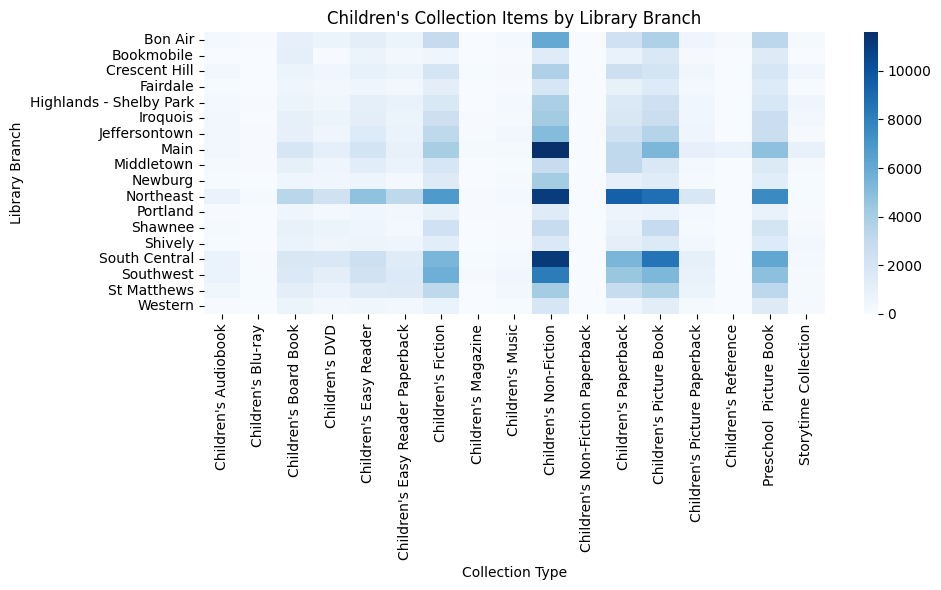

In [149]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='Blues')

plt.title("Children's Collection Items by Library Branch")
plt.xlabel("Collection Type")
plt.ylabel("Library Branch")

plt.tight_layout()
plt.savefig('../plots/ChildrensCollectionHeatMap.png')
plt.show()

In [150]:
teen_words = ['Teen', 'College']
pattern = '|'.join(teen_words)
teens_df = df[
    df['item_collection'].str.contains(pattern, case=False, na=False)]

In [151]:
teens_df_byloc = teens_df.groupby(['item_location', 'item_collection']).size().reset_index(name='count')
teens_df_byloc

,item_location,item_collection,count
0,Bon Air,Older Teen Fiction,1170
1,Bon Air,Older Teen Paperback,2
2,Bon Air,OlderTeen Audiobook,63
3,Bon Air,Teen Non-Fiction,1318
4,Bon Air,Younger Teen Audiobook,85
...,...,...,...
133,Western,Teen Non-Fiction,777
134,Western,Teen Reference,1
135,Western,Younger Teen Audiobook,21
136,Western,Younger Teen Fiction,298


In [152]:
heatmap_data = teens_df_byloc.pivot(
    index='item_location',
    columns='item_collection',
    values='count'
).fillna(0)

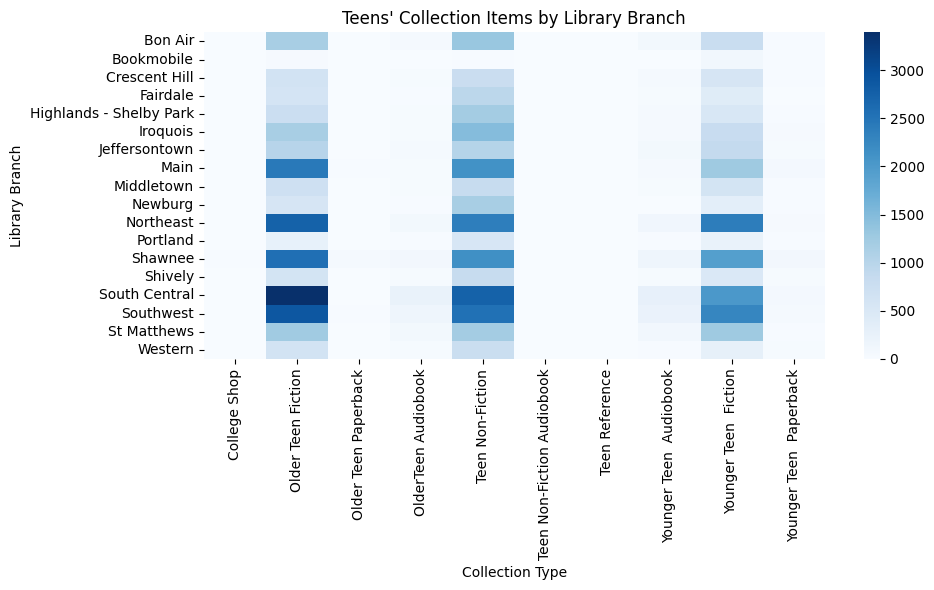

In [153]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='Blues')

plt.title("Teens' Collection Items by Library Branch")
plt.xlabel("Collection Type")
plt.ylabel("Library Branch")

plt.tight_layout()
plt.savefig('../plots/TeensCollectionHeatMap.png')
plt.show()

In [154]:
adult_words = ['Adult', 'ELL', 'Mystery', 'Science', 'Western', 'International', 'Kentucky', 'Natural', 'Oversize','Holiday', 'Urban', 'Bestsellers', 'Large', 'Caldecott/Newberry', 'Government', 'Telereference', 'Big', 'Magazines']
pattern = '|'.join(adult_words)
adults_df = df[
    df['item_collection'].str.contains(pattern, case=False, na=False)]

In [155]:
adults_df_byloc = adults_df.groupby(['item_location', 'item_collection']).size().reset_index(name='count')
adults_df_byloc

,item_location,item_collection,count
0,Bon Air,Adult Audiobook,2496
1,Bon Air,Adult Blu-Ray,156
2,Bon Air,Adult DVD,2714
3,Bon Air,Adult Fiction,13533
4,Bon Air,Adult Non-Fiction,19982
...,...,...,...
338,Western,Mystery,324
339,Western,Oversize,23
340,Western,Science Fiction,68
341,Western,Urban Fiction,725


In [156]:
heatmap_data = adults_df_byloc.pivot(
    index='item_location',
    columns='item_collection',
    values='count'
).fillna(0)

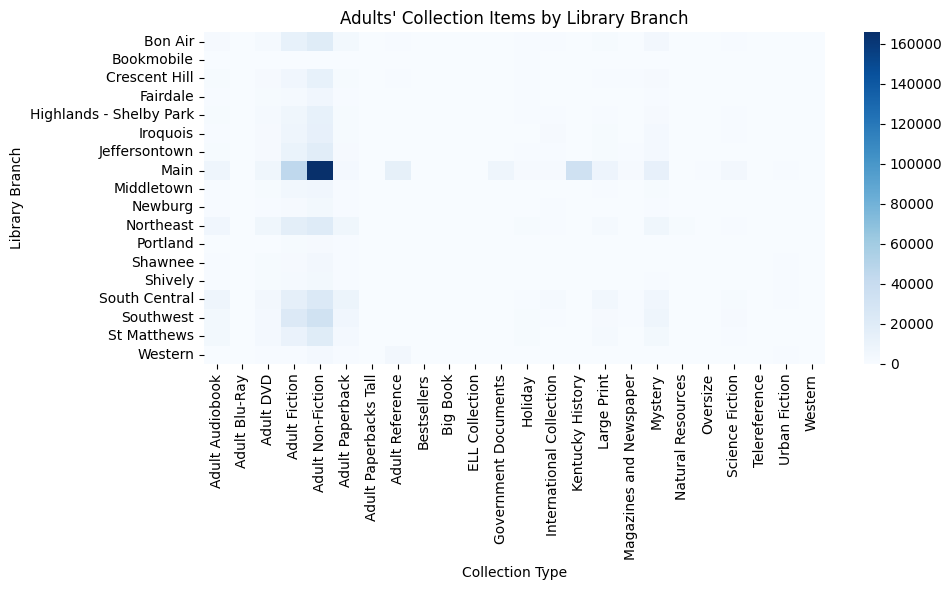

In [157]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='Blues')

plt.title("Adults' Collection Items by Library Branch")
plt.xlabel("Collection Type")
plt.ylabel("Library Branch")

plt.tight_layout()
plt.savefig('../plots/AdultsCollectionHeatMap.png')
plt.show()

In [158]:
df.to_csv('../data/Clean/clean_lfpl_inventory.csv', index=False)